In [9]:
import matplotlib.pyplot as plt
import numpy as np

from utils.fit_data import ResonanceFitData
from utils.pendulums_data import PendulumsData, prepare_data
from utils.plotting import bar_charts, plot_transient_decay, save_plot

In [10]:
lengths = np.array([0.97, 0.99, 0.995, 1.0])
labels = ["97cm", "99cm", "99.5cm", "100cm"]

cols = ["mass A", "mass B", "mass C", "mass D"]
L_d = 1.0

In [11]:
increased_mass = PendulumsData(
    cols, labels, lengths, prepare_data("../data/session-6/increased-mass.csv", cols)
)
doubled_mass = PendulumsData(
    cols, labels, lengths, prepare_data("../data/session-6/doubled-mass.csv", cols)
)
short_dress = PendulumsData(
    cols, labels, lengths, prepare_data("../data/session-6/short-skirt.csv", cols)
)
long_dress = PendulumsData(
    cols, labels, lengths, prepare_data("../data/session-6/long-skirt.csv", cols)
)

In [12]:
# remove origin axis differences
increased_mass.preprocess_offsets()
doubled_mass.preprocess_offsets()
short_dress.preprocess_offsets()
long_dress.preprocess_offsets()

In [13]:
increased_mass_fit = ResonanceFitData(L_d, increased_mass)
doubled_mass_fit = ResonanceFitData(L_d, doubled_mass)
short_dress_fit = ResonanceFitData(L_d, short_dress)
long_dress_fit = ResonanceFitData(L_d, long_dress)

In [14]:
increased_mass_fit.fit_single_pendulums()
doubled_mass_fit.fit_single_pendulums()
short_dress_fit.fit_single_pendulums()
long_dress_fit.fit_single_pendulums()

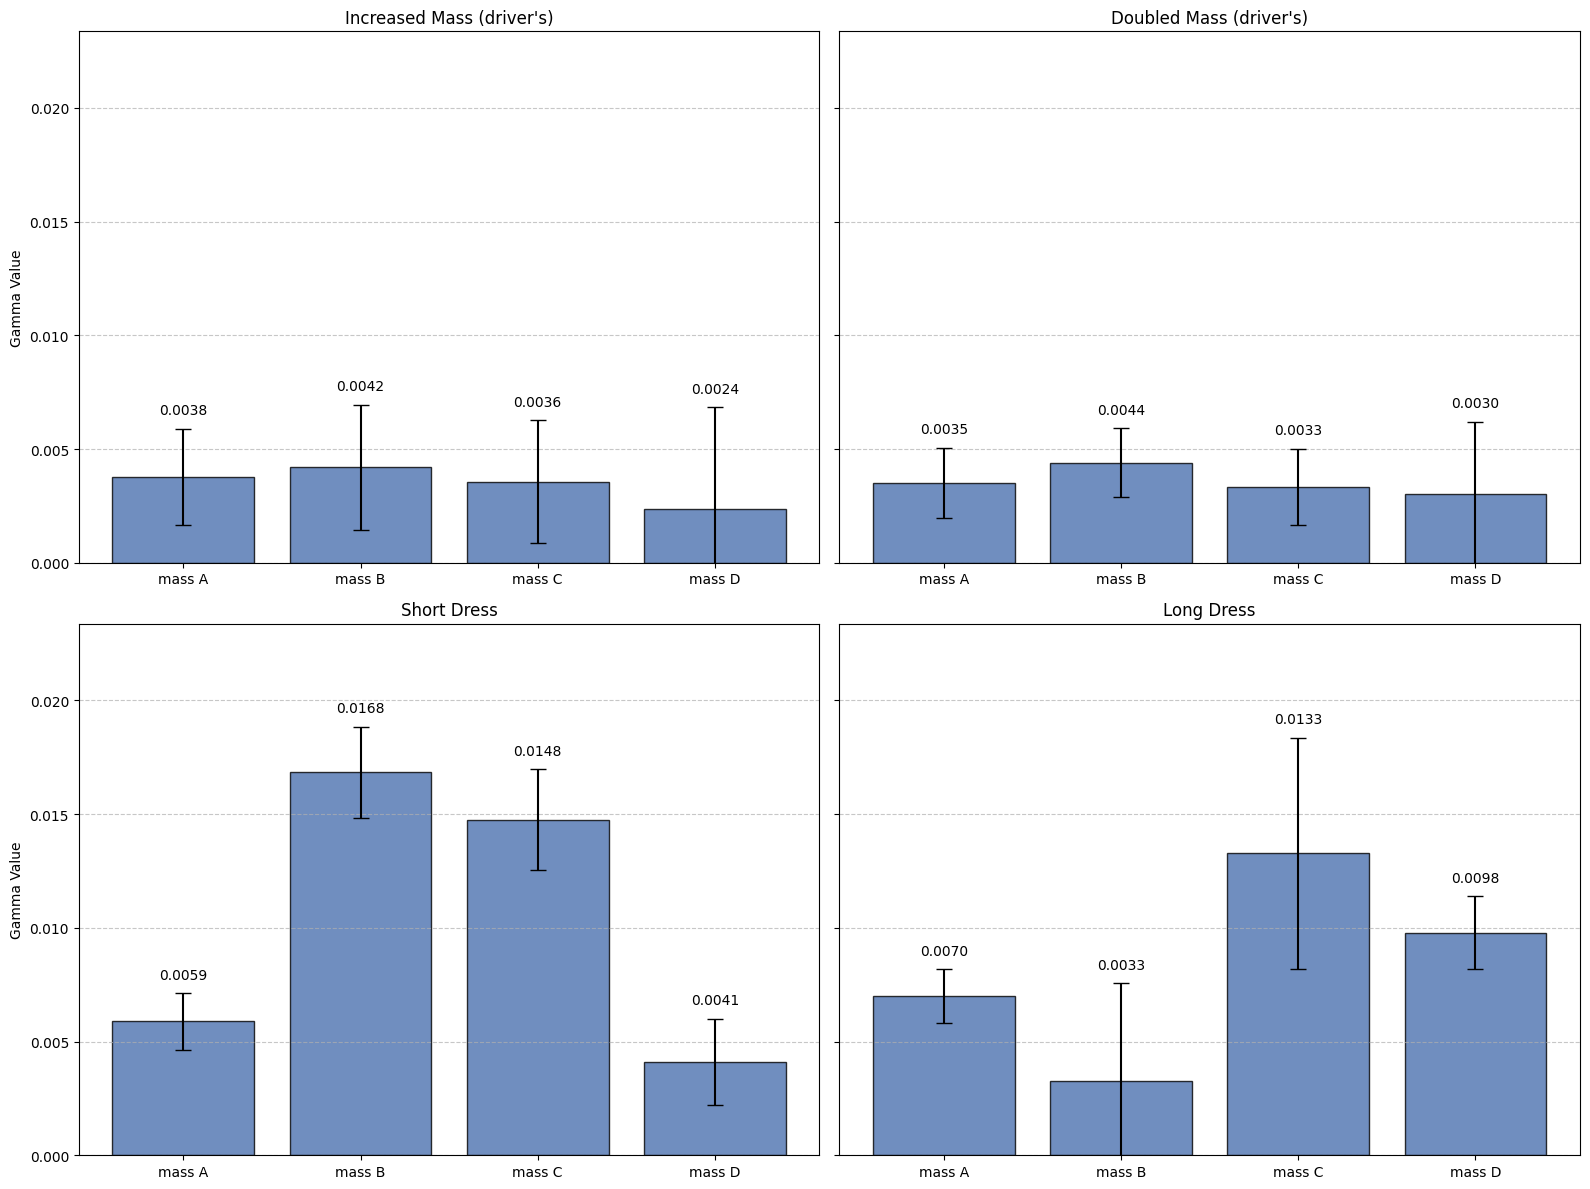

In [15]:
bar_charts(
    [
        increased_mass_fit.get_data_to_plot(),
        doubled_mass_fit.get_data_to_plot(),
        short_dress_fit.get_data_to_plot(),
        long_dress_fit.get_data_to_plot(),
    ],
    [
        "Increased Mass (driver's)",
        "Doubled Mass (driver's)",
        "Short Dress",
        "Long Dress",
    ],
)
save_plot("session-6-single/summary-single.png")
plt.show()

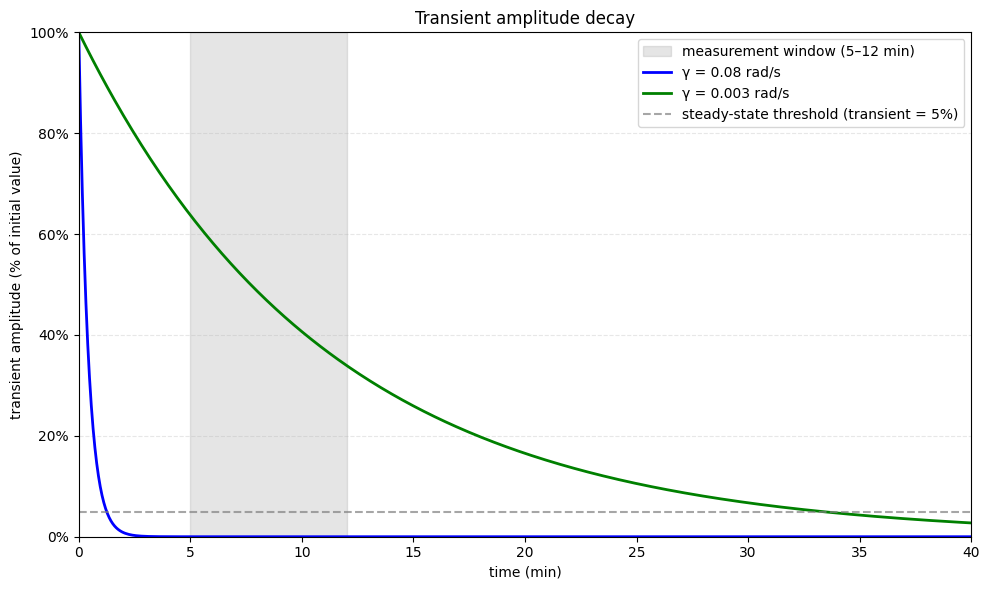

In [16]:
plot_transient_decay([0.08, 0.003], (0, 40), (5, 12), round_digits=4)
save_plot("session-6-single/transient-decay.png")
plt.show()